# Lab 057 · Cross-family ensembling

**Skill:** build an OOF probability stack and evaluate a validation-selected combination against a validation-selected single model. [Lesson](../lessons/0057-cross-family-ensembling.html) · [Reference](../reference/cross-family-ensembling.html) · [Contract](l057-reproduction.md).

**Before input:** explain why an OOF fold cannot also be its predictor's early-stopping set; why test-selected best-single is an oracle; and why more folds do not mean more independent datasets. Write your answers before proceeding.

PROVIDED = read/run; TODO = implement; CHECK = immediate feedback; EXIT = submit evidence and interpretation. Five live TODO functions drive both the OOF trainer and complete three-family audit. Allow 45–60 minutes learning plus training time. No GPU or checkpoint download is needed for the main worksheet: it trains a small tree/TabM example and audits committed author XGB/TabM/TabICL predictions. The gated fresh-three-family/scale-up track downloads a 108 MB checkpoint and uses the exact same visible code.

**Mirror scope:** OOF construction + Caruana greedy combiner from scratch; the known L054 TabM source is visible below. XGB is a provided base library; TabICL is a provided pretrained API baseline, not an architecture/pretraining reproduction. Small numeric OpenML tables are Tier A substitutes for TabArena's 51-task roster. Fixed recipes, 3 folds, log loss and fold-averaged TabICL differ from the paper. Exact Figure 6 verdict: **INCOMPARABLE**. Model seeds 0/1/2; row/outer/fold seed57. Version, dataset hash, row IDs and checkpoint hash are recorded in the author evidence. The synthetic four-row example only isolates a mechanism.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Use complementary predictions without teaching on their answers

<a href="../lessons/0054-tabm-parameter-efficient-ensembling.html">TabM</a> combined related members; <a href="../lessons/0056-tabarena-benchmark-literacy.html">TabArena</a> compared whole fitted families. Cross-family ensembling connects those ideas by combining predictors with different biases. The statistical opportunity is error cancellation. The engineering requirement is equally central: every training prediction used by the combiner must come from a base procedure that excluded that row’s target.

**Connecting the ideas.** A benchmark can show which methods lead, but it does not establish whether their predictions complement one another. Inspect disagreement at the probability level: averaging only helps when it changes the errors that matter to the chosen score.

## Concept recap

A binary prediction is the probability of class 1. A convex mixture uses weights at least zero that sum to one, so its output stays a valid probability. Mixing hard predictions discards information. Log loss is negative mean log probability assigned to the correct class; lower is better.

OOF predictions are generated by models fitted without the predicted row. Keep that row out of learned preprocessing, early stopping and in-context labels too. One row gets one OOF probability per family; row order must be restored when folding ends. Test predictions instead average the fitted fold models within each family.

A greedy combiner tries adding each family's OOF probabilities to the running sum. Pick the lowest-loss trial average and allow replacement. A selected sequence [A,A,B,A] means weights [.75,.25]. Retain the best OOF prefix of the fixed-length search, then freeze weights before test evaluation. OOF labels train this second-level model; OOF loss is not its unbiased evaluation.

In the synthetic example below, A and B each have loss .8574, but their opposite error patterns give a 50/50 mixture loss .5978. Duplicating A cannot help. This is evidence about these four probabilities, not evidence that arbitrary family mixtures improve every real dataset.

### Diversity is a statement about errors on the same rows

Two models can have equal accuracy and still disagree on which examples are difficult. If their errors are complementary, combining their probability estimates may improve prediction. If they make the same confident mistakes, averaging adds little protection. Compare aligned outputs on the same observations before interpreting a family-level diversity story.

For a positive example, probabilities 0.9 and 0.3 average to 0.6. Their individual log losses are about 0.105 and 1.204, while the ensemble loss is about 0.511. Averaging has improved on the weak model and worsened relative to the strong model on this row. Across rows, the balance depends on where each member is strong.

Because negative logarithm is convex, the loss of an average true-class probability is no greater than the average of individual log losses on that row. This does **not** guarantee that the ensemble beats the best individual model across the dataset. The best member may consistently dominate the rest.

Different architectures are a plausible source of complementary error, not proof of it. Trees, MLP ensembles and retrieval models differ in representation and information use, but they can still learn highly correlated predictors. Measure residual or probability dependence and task-level ensemble gains rather than using different names as a diversity metric.

An ensemble also inherits its members' information requirements. If one branch uses an illegal feature or leaked target, averaging it with legal branches does not repair the boundary. Audit each member before studying how to combine them.

### Derive what averaging guarantees, and what it does not

Write qᵢⱼ for the probability model j assigns to the **true** class on row i: qᵢⱼ=pᵢⱼ when yᵢ=1, and qᵢⱼ=1−pᵢⱼ when yᵢ=0. For nonnegative weights summing to one, the mixture assigns qᵢ=Σⱼwⱼqᵢⱼ to that class. The row loss is −log(qᵢ), measured in nats because log is the natural logarithm. The second derivative of −log(q) is 1/q²>0, so the curve is convex. Jensen's inequality therefore gives −log(Σⱼwⱼqᵢⱼ)≤Σⱼwⱼ[−log(qᵢⱼ)]. Averaging over rows gives the same inequality for dataset log loss.

The right side is the **weighted mean loss**, not the minimum member loss. Take true-class probabilities .9 and .3 on every row. Equal mixing yields .6 and loss .5108: better than the members' average loss .6547 but worse than the consistently better member's .1054. Diversity cannot rescue an arbitrarily poor library. Conversely, if the two members swap .9/.3 across two rows, both individual losses average .6547 and the mixture improves to .5108. The same individual mean qualities support different ensemble gains because their errors occur on different rows.

For squared error, the same idea has an exact decomposition. Let e₁=p₁−y and e₂=p₂−y be residual vectors. Then MSE(αp₁+(1−α)p₂)=α²E[e₁²]+(1−α)²E[e₂²]+2α(1−α)E[e₁e₂], where E is the average over these rows. The cross-product controls whether errors reinforce or cancel. Pearson residual correlation subtracts means and divides by standard deviations; it is not that cross-product unless you restore the scale and mean terms. For log loss the preceding convexity inequality applies, but this quadratic identity does not. A correlation heatmap alone cannot certify a log-loss benefit.

**Predict before calculating:** if A and B return exactly the same probability vector, can any convex weight change predictions? What if B is simply a different family name for A's predictions? The answer is no in both cases. The mechanism lives in aligned outputs, not the labels “tree” and “neural.”

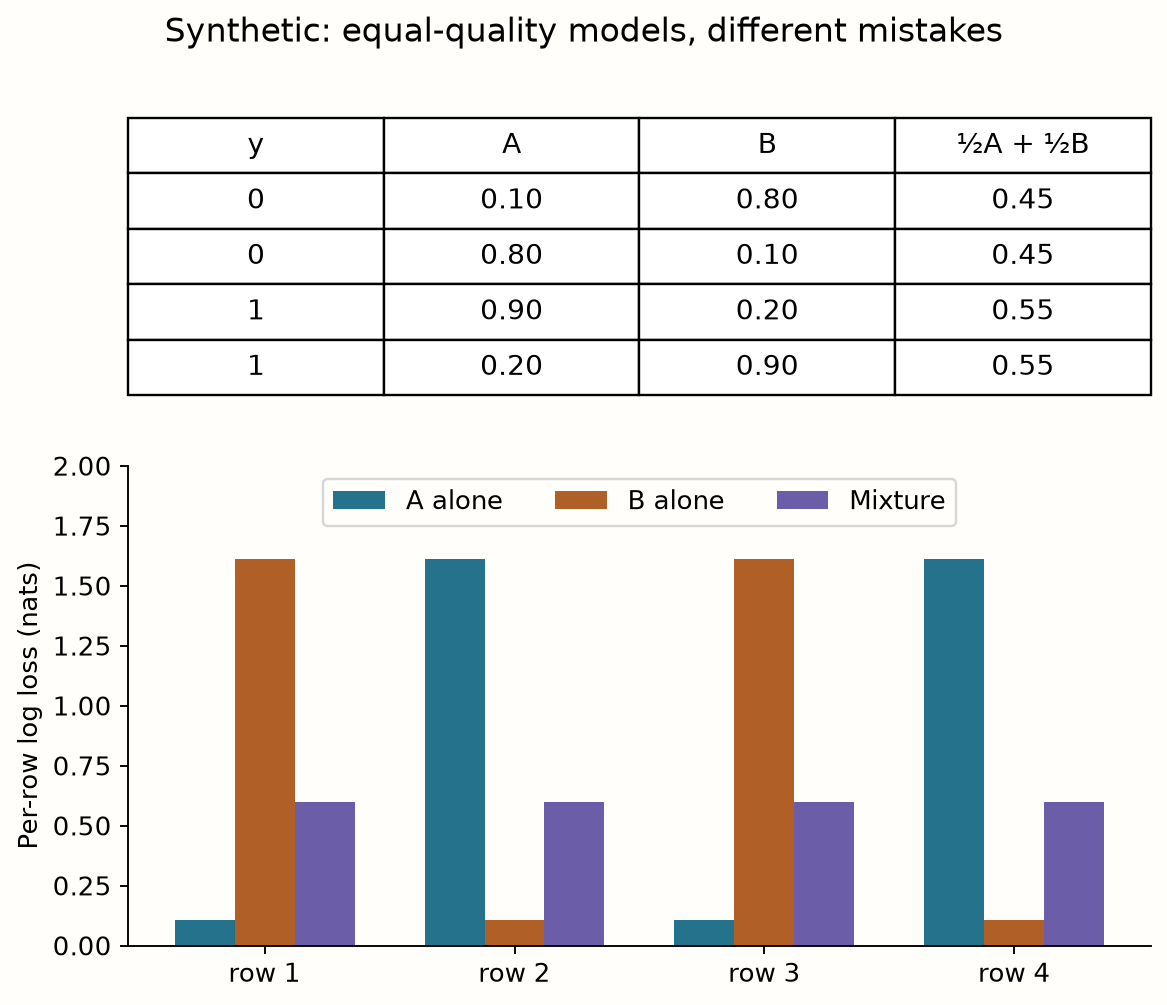

Synthetic mechanism: equal individual quality, complementary row errors. The mixture uses probabilities, not logits.

**Connecting the ideas.** Complementarity motivates a combiner. Training one on in-sample base predictions would give it an unrealistically easy task, so the whole architecture is organized around held-out folds and row-ID alignment. This is why OOF construction precedes weight selection.

### Cross-family stacking: each training row needs an honest prediction

**Trace before reading:** Why is a held-out base prediction still unsafe if its preprocessing saw the row?

<div style="max-width:100%;overflow-x:auto">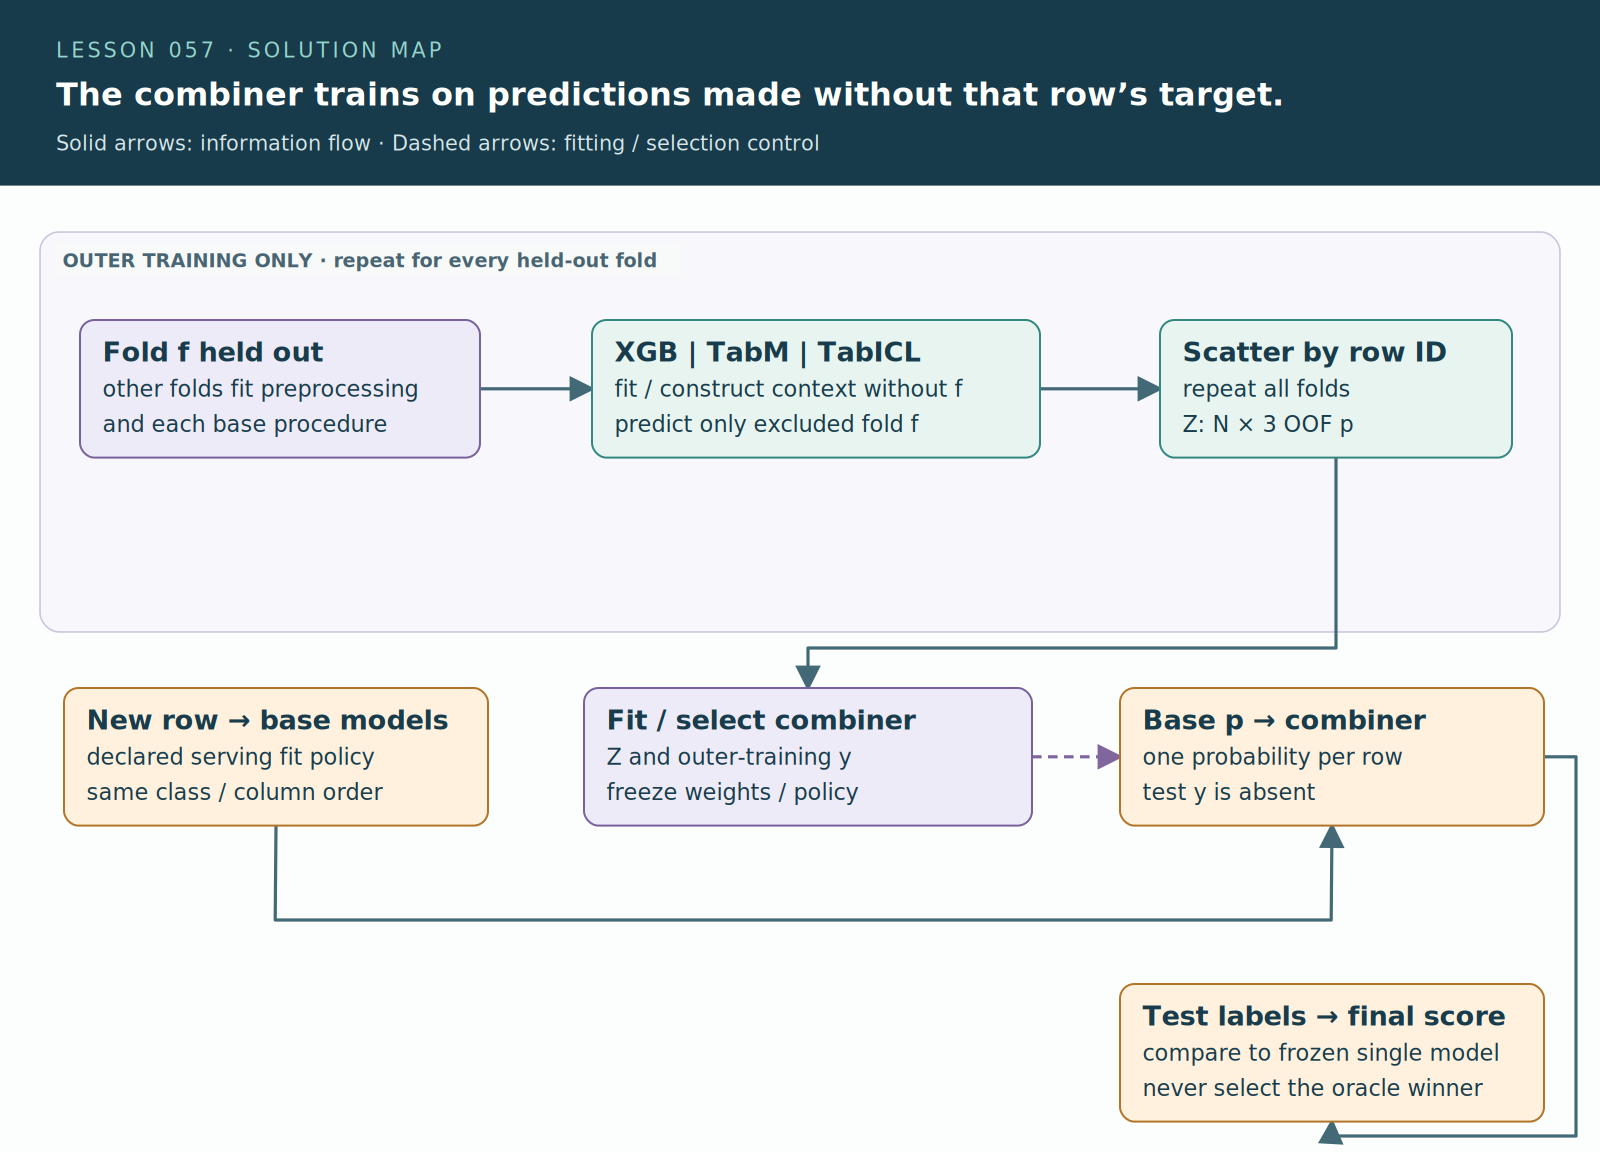</div>

**How the parts work together:** The entire fitted base procedure must exclude the held-out fold. After scattering OOF predictions into original row order, the combiner may use those rows’ labels. Test scoring waits until both base-serving and combiner policies are frozen.

**Pictured scope:** OOF procedure with XGBoost, TabM and provided TabICL predictions. The serving refit/fold policy is a declared part of the artifact, not inferred from this schematic.

[Full-size vector diagram](../assets/solution-maps/0057-oof-system.svg). Scroll on narrow screens to keep labels legible.

<details><summary>Text route: components and connections</summary><ol><li><strong>Fold f held out</strong>: other folds fit preprocessing; and each base procedure. Connects to XGB | TabM | TabICL.</li><li><strong>XGB | TabM | TabICL</strong>: fit / construct context without f; predict only excluded fold f. Connects to Scatter by row ID.</li><li><strong>Scatter by row ID</strong>: repeat all folds; Z: N × 3 OOF p. Connects to Fit / select combiner.</li><li><strong>Fit / select combiner</strong>: Z and outer-training y; freeze weights / policy. Connects to Base p → combiner (fitting/selection control).</li><li><strong>New row → base models</strong>: declared serving fit policy; same class / column order. Connects to Base p → combiner.</li><li><strong>Base p → combiner</strong>: one probability per row; test y is absent. Connects to Test labels → final score.</li><li><strong>Test labels → final score</strong>: compare to frozen single model; never select the oracle winner.</li></ol></details>

## 4. Model architecture: the OOF stack



*Out-of-fold (OOF)* means that a row’s base prediction came from a model fitted without that row. Partition the outer development set into K folds. For fold f, fit each family on the other K−1 folds and predict f. Scatter predictions back into their original row positions. Every development row must be covered exactly once. This creates `Z ∈ [0,1]^(N×M)`: N development rows, M families, one positive-class probability per cell.




The family branches are: XGBoost, a sum of boosted trees; corrected numeric TabM-mini from L054 (v2), three width-48 hidden blocks with eight internal members and mean member probabilities; and the released TabICL v1.1 classifier, which conditions its pretrained inference on labeled fitting rows. TabICL’s weights are loaded, not pretrained here. No held-out or test label is included in its context. We use one transformed view locally, versus its 32-view default. This is a large resource reduction, so it is not a strong-default TabICL claim. [TabICL implementation](https://pypi.org/project/tabicl/0.1.4/); exact package and checkpoint identities are in [provenance](_sources_l057.json).




For XGBoost and TabM, the imputer’s medians and scaler’s means/standard deviations are fitted only on the complementary training folds. TabICL fits its internal preprocessing on those rows. **Early stopping on the OOF fold would let its labels influence the model that predicts it.** Our fixed epochs/tree counts avoid this. If you add early stopping or HPO, create an inner validation split entirely within the complementary rows.




The older L018 widget traces row eligibility. The lab extends it to three aligned columns and fit-only preprocessing. Fold membership may be stratified to preserve class proportions; that standard splitter use of labels is different from training on a held-out target.




At inference, average the K fold-model predictions within each family, making `Z_test ∈ [0,1]^(N_test×M)`. Apply the frozen weights: `p_test=Z_test w`. Do not average K copies into the OOF row: each OOF row has exactly one eligible model per family. Our choice also avoids an unexamined full-data refit shift, though fold-averaged test predictions still differ from single-fold OOF predictions. A linear probability combiner trained on OOF features is a constrained stack; it is not logistic-regression stacking or AutoGluon’s complete multilevel stack.

### Follow one row into the combiner's training matrix

Suppose training rows are partitioned into folds A, B and C. To construct out-of-fold predictions for a row in A, train each base family on B∪C and predict that row using its features. Place those predictions in the row's original position in a matrix Z. Repeat for B and C. Every row now has base predictions generated by models that did not train on its target.

For three base families in binary classification, Z has shape N×3 if each column stores positive-class probability. Column identity matters: column 0 must represent the same family for every row, and row i must still correspond to target yᵢ. Concatenating fold outputs without restoring row order can produce a numerically valid matrix paired with the wrong targets.

The meta-model trains on (Z,y). It is allowed to use y here because this is its supervised training set. The protection is that the features Z were generated without training the relevant base predictor on the same row's target. The distinction is between a target used to train the combiner and a target leaked into that row's base prediction.

Now consider a tempting shortcut: train each base model on all N rows, predict those same rows, and fit the combiner. Flexible base models can produce unrealistically confident in-sample outputs. The combiner learns how to combine those optimistic signals, then sees a different output distribution at deployment. OOF construction reduces this mismatch.

OOF is not magic independence. Rows can share entities or time structure. If the deployment question requires grouped or forward validation, the folds used to generate Z must respect that structure too. Random OOF folds cannot repair an inappropriate outer split.

### State which OOF convention you mean

Some benchmark frameworks call predictions OOF when the row is excluded from weight updates, even if its fold's labels select an early-stopping epoch. Lesson 056 describes that framework convention. Such labels can still influence the final predictor through model selection. Here we deliberately use a stricter policy: fixed training lengths, so neither fitting nor epoch selection uses the predicted fold's labels. If early stopping is added, split validation rows from the fitting complement. This strengthens the combiner-feature boundary; it is a protocol deviation from framework OOF, not a claim that the historical benchmark ran our policy.

### The inference route must match a declared policy

For a new test row, you need base predictions in the same column order. One policy averages predictions from the saved fold models. Another refits each family on the full eligible training set. These policies have different training sizes and can yield different probability distributions. State which one the local implementation uses and keep validation selection consistent with it.

In [ ]:
# PROVIDED — setup and versions
import os,sys,json,hashlib,math,importlib.metadata,time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import rankdata,friedmanchisquare,studentized_range,t
from threadpoolctl import threadpool_limits
from xgboost import XGBClassifier
from IPython.display import display
for p in (Path.cwd(),Path.cwd()/'labs',Path.cwd().parent):
    if (p/'relkit').is_dir():
        ROOT=p.resolve();os.chdir(ROOT);sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Start in the course workspace or run Colab bootstrap')
from relkit.data import load_tier_a,SPECS,CACHE
print({p:importlib.metadata.version(p) for p in ['numpy','scipy','scikit-learn','torch','xgboost']})
torch.set_num_threads(1)

## TODO 1 · Exclude the predicted fold
**Goal:** return original row positions whose fold ID differs from heldout. **Why:** no row should train its own base predictor. **Hint boundary:** preserve row identity; do not return fold IDs or a shuffled subset.

In [ ]:
# TODO — train_indices
def train_indices(fold_ids, heldout):
    raise NotImplementedError("Implement the operation described above")

In [ ]:
# CHECK — noncontiguous fold rows and complement
np.testing.assert_array_equal(train_indices(np.array([0,1,0,2,1]),1),[0,2,3])
assert len(set(train_indices(np.array([0,1,0,2,1]),1)) & {1,4})==0
print('PASS: fold complement')

## TODO 2 · Assemble aligned predictions
**Goal:** mutate a [rows,families] matrix and integer coverage vector. Scatter predictions to original integer indices and increment coverage. **Why:** stacking mismatched rows can pass shape checks while learning nonsense. Reject repeated/out-of-range/noninteger indices, previously filled rows, wrong shapes and nonfinite or out-of-range probabilities. **Hint boundary:** perform validation before mutation. Return value is not used.

In [ ]:
# TODO — write_oof
def write_oof(matrix, seen, indices, predictions):
    raise NotImplementedError("Implement the operation described above")

In [ ]:
# CHECK — shuffled arrival, duplicate and invalid probability guards
z=np.full((4,2),np.nan);seen=np.zeros(4,int)
write_oof(z,seen,np.array([2,0]),np.array([[.2,.4],[.1,.3]]))
np.testing.assert_allclose(z[[0,2]],[[.1,.3],[.2,.4]])
for ix,pred in [(np.array([0]),np.array([[.2,.4]])),(np.array([1]),np.array([[np.nan,.3]]))]:
    try:write_oof(z,seen,ix,pred)
    except ValueError:pass
    else:raise AssertionError('Duplicate or invalid OOF prediction accepted')
assert seen.tolist()==[1,0,1,0]
print('PASS: original row alignment and coverage protection')

## TODO 3 · Combine probabilities
**Goal:** map [rows,models] predictions and [models] weights into [rows] probabilities. **Why:** class/row alignment and convex weights are the prediction contract. Reject wrong dimensions, nonfinite or out-of-range probabilities, negative/nonfinite weights and a weight sum unequal to one (allow floating tolerance). **Hint boundary:** do not renormalize invalid inputs silently.

In [ ]:
# TODO — blend
def blend(predictions, weights):
    raise NotImplementedError("Implement the operation described above")

In [ ]:
# CHECK — actual arithmetic and convexity
np.testing.assert_allclose(blend(np.array([[.2,.8],[.4,.6]]),[.75,.25]),[.35,.45])
for w in ([-.1,1.1],[1,1],[np.nan,0]):
    try:blend(np.ones((2,2)),w)
    except ValueError:pass
    else:raise AssertionError('Invalid weights accepted')
print('PASS: convex prediction')

**Connecting the ideas.** The OOF matrix now supplies honest base features for each training row. The next adaptive decision is the combiner itself: choose weights using allowed validation information and freeze both the combiner and serving policy before test.

## 5. Learn the weights without test labels



We implement [Caruana et al.’s forward ensemble selection](https://www.cs.cornell.edu/~alexn/papers/shotgun.icml04.revised.rev2.pdf): start empty; try adding each candidate’s OOF predictions to the current sum; choose the candidate with lowest OOF log loss; allow selection with replacement. Repeated selection gives a useful model more weight. For selection counts [3,1,0], the weights are [.75,.25,0]. Inference needs each selected model once, not three separate runs of the first model.




candidate_j(t) = (S_(t−1) + Z[:,j]) / t  
j_t = argmin_j logloss(y_dev, candidate_j(t))  
S_t = S_(t−1) + Z[:,j_t]  
w_j = count(j in the retained prefix) / prefix_length




*t* starts at one; *S* is the sum of chosen prediction vectors, initially zero. We run 40 steps and retain the prefix with best OOF loss. The current step need not improve on the preceding step: adding an equally weighted member can worsen the mixture. Retaining the best prefix preserves the best single candidate’s OOF loss, because step one is included. It does *not* preserve or improve its test loss.





The notebook shows this implementation and keeps your TODO functions live in both training and audit paths. A check executes the [pinned upstream selector](https://github.com/autogluon/autogluon/blob/946b65c683e975df34456bbe1f68366c8f4570be/core/src/autogluon/core/models/greedy_ensemble/ensemble_selection.py) with a local log-loss adapter: weights match on five non-tied fixtures. Upstream rounding and tie handling differ; this is a bounded primitive check, not full-library or historical TabArena parity.




**Best-single comparator:** select the lowest-loss family on OOF predictions and evaluate that frozen choice on test. Reporting the family with the best test score as the deployable comparator uses an oracle: a choice unavailable before test labels. Show individual test scores descriptively, but keep this distinction in the headline gap.



OOF labels are still the combiner’s training labels. Trying hundreds of libraries, fold schemes and weight searches on them can overfit selection. The untouched outer test evaluates the whole selected procedure; nested outer evaluation is needed if you keep redesigning it. Lesson 059 studies this failure mode.



**Source check on the actual corrected libraries:** four of nine weight vectors match the pinned upstream selector exactly. Five differ because its six-decimal score rounding changes near-tied prefixes (maximum probability difference .003731, maximum OOF loss difference 7.44×10⁻⁷). A separate diagnostic disables only that rounding in the reference; then all nine match. This altered-reference diagnostic explains the mismatch; it is not exact upstream parity. [Full measured source comparison](_source_check_l057_v2_results.json).

### A probability matrix needs a class schema

For multiclass outputs, each member may expose probabilities in its own class order. Suppose one returns columns [cat,dog] and another [dog,cat]. Averaging the raw arrays combines different events. Align by class label before averaging, and verify that each row remains a valid probability distribution.

In binary classification, storing only positive-class probability is compact, but the positive label must be fixed. The numbers 0.8 and 0.2 may describe the same belief if different implementations disagree about which class is positive. Save class labels with predictions rather than inferring them from array position later.

A convex weighted ensemble uses nonnegative weights that sum to one. If predictions p₁ and p₂ are 0.8 and 0.4 with weights 0.25 and 0.75, the result is 0.5. Nonnegative normalized weights preserve the probability range and, for multiclass vectors, the unit sum. An unconstrained linear combination does not automatically have those properties.

The combiner's objective matters. Minimizing log loss favors calibrated true-class probability, while maximizing a ranking metric can tolerate substantial calibration differences. If the deployment decision uses probability thresholds or expected cost, inspect calibration in addition to discrimination.

Regularization controls how strongly the combiner can exploit the finite OOF sample. With many candidate members and few rows, learned weights can overfit even though each base prediction was honestly cross-fitted. Select the combiner's regularization using the declared validation boundary; OOF construction does not authorize unlimited test-guided experimentation.

### Two different learning problems hide inside the paper's ensemble

A **configuration** fixes a family and its hyperparameters, such as XGBoost depth 3 versus depth 6. A **library** is the set of already fitted candidate predictors whose aligned predictions can be combined. A **portfolio** is an ordered list of configurations to attempt under a training budget on a new dataset. Portfolio construction decides which models become available; greedy selection decides how to combine those that actually finished. These are different learning problems.

[TabArena v1 §3.2 and Appendix C.3](https://arxiv.org/html/2506.16791v1#A3.SS3) specify a learned portfolio of size 200, leave-one-dataset-out construction, a time-limited sequence of configuration evaluations, and 40 post-hoc selection steps. Figure 6 is simulated from saved artifacts. Thus its result is not simply “average three named families.” Our three fixed configurations remove portfolio learning, HPO and the time-budget stopping rule. That makes the operation easier to inspect, but limits the paper claim we can test.

Imagine datasets A, B and C. To evaluate a learned portfolio on C, use only A and B to choose its ordering. On C, fit the ordered candidates using C's development data, select weights using C's OOF labels, and finally score on C's outer test labels. It is legitimate to learn the combiner on C; that is part of adapting a supervised model to C. It is not legitimate to use C's eventual test performance to learn the portfolio that is then advertised as transferring to C.

*Read the diagram from top to bottom. The crossed boundary is a dataset boundary first, then a row boundary inside the evaluation dataset. The local lab implements the lower two stages with a prespecified three-member library; the portfolio stage is explained but not run.*

This matters for the relational mission. If a future GNN is added after inspecting which RelBench tasks favor it, the selection of tasks/configurations is itself part of the research procedure. Entity and temporal separation must hold inside each task, and cross-task meta-selection must also exclude the task on which transfer is claimed. Random OOF rows do not solve either problem automatically.

### What Caruana-style includes here

The [corrected Caruana et al. paper, §§1–3 and §9](https://www.cs.cornell.edu/~alexn/papers/shotgun.icml04.revised.rev2.pdf) uses a held-out hillclimbing set and studies a much larger library. We adapt the selector to OOF features. Replacement and best-prefix retention are implemented; sorted initialization and bagged selection over subsets of library members are omitted. Bagging candidate members is different from bootstrapping training rows. The paper's complete empirical recipe and our four-line recurrence should therefore not share a reproduction label.

At step t, a candidate's new weight is 1/t, while every existing selected occurrence receives that same weight. This is a constrained discrete search, not a gradient optimizer over all real-valued weights. Increasing t refines the attainable fractions but can also increase adaptation to noisy OOF labels. In the four-row trace the second step finds [.5,.5]; the third must choose either [2/3,1/3] or [1/3,2/3], both worse. Best-prefix retention keeps step two. A fixed step budget bounds work; it does not remove statistical overfitting.

The pinned AutoGluon reference also keeps a best prefix, but rounds some losses and resolves ties differently. Two selectors can produce different weights on duplicated columns yet identical predictions. Our parity check uses non-tied fixtures; our exact-tie check asserts the declared first-column rule. Do not reinterpret one as proof of the other. For N rows, M candidate columns and T steps, evaluating all binary log-loss candidates costs O(NMT); base fitting often dominates, but a very large saved library can make selection costly too.

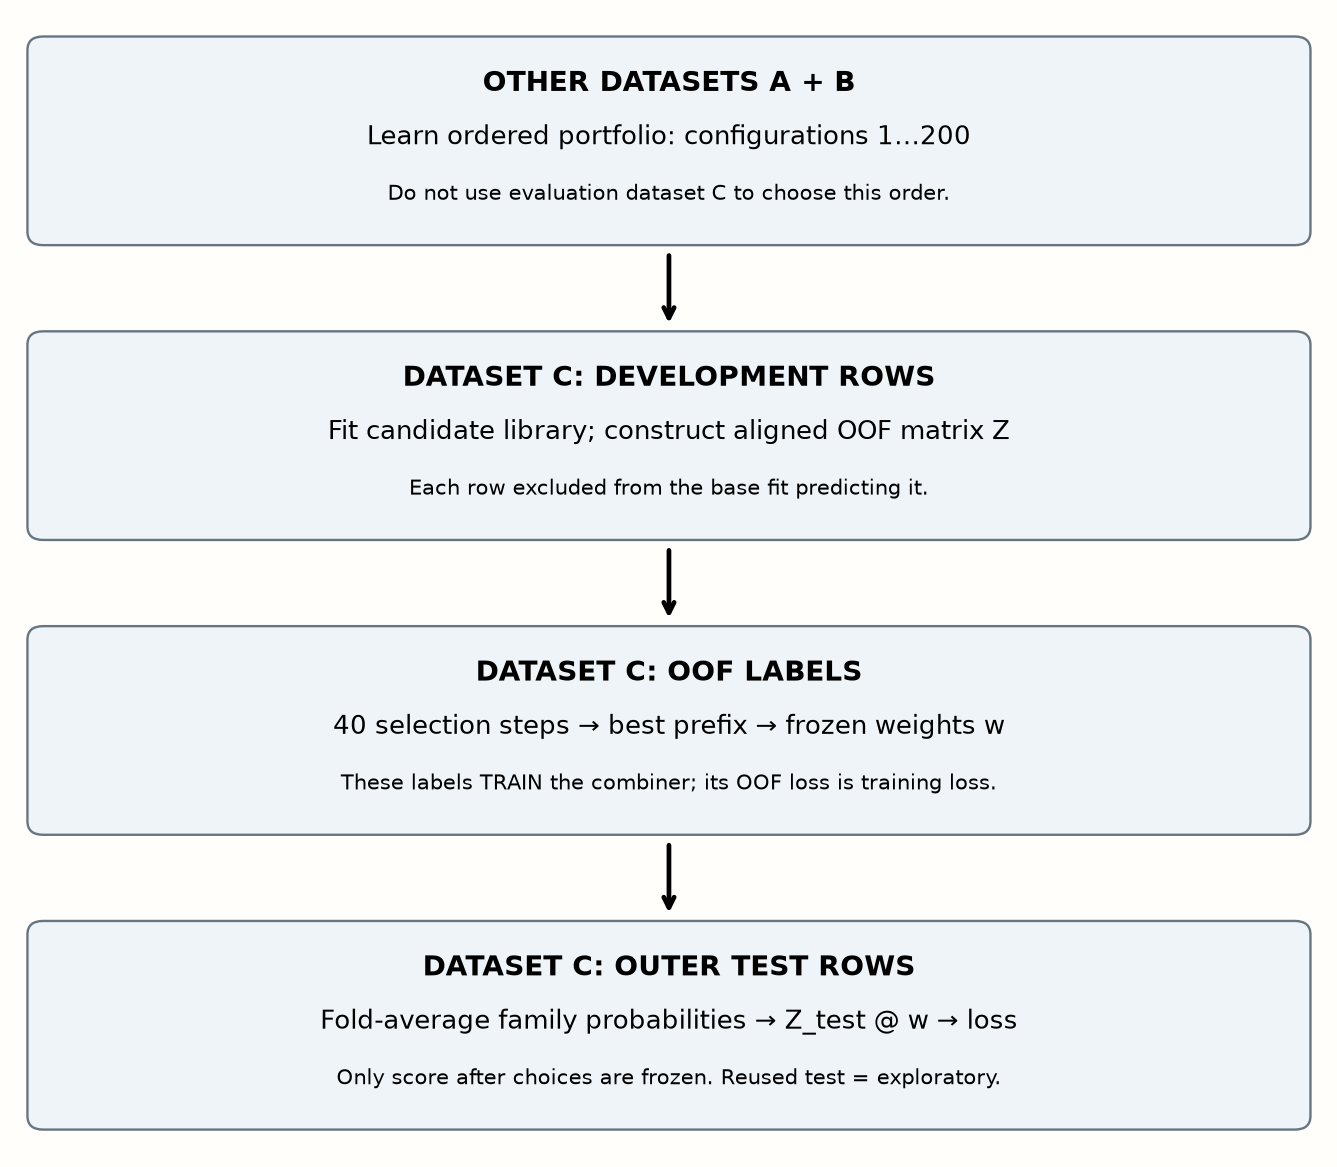

Other datasets choose a portfolio; target-task development rows train its library and combiner; test rows evaluate frozen choices. The local lab fixes the three-member library.

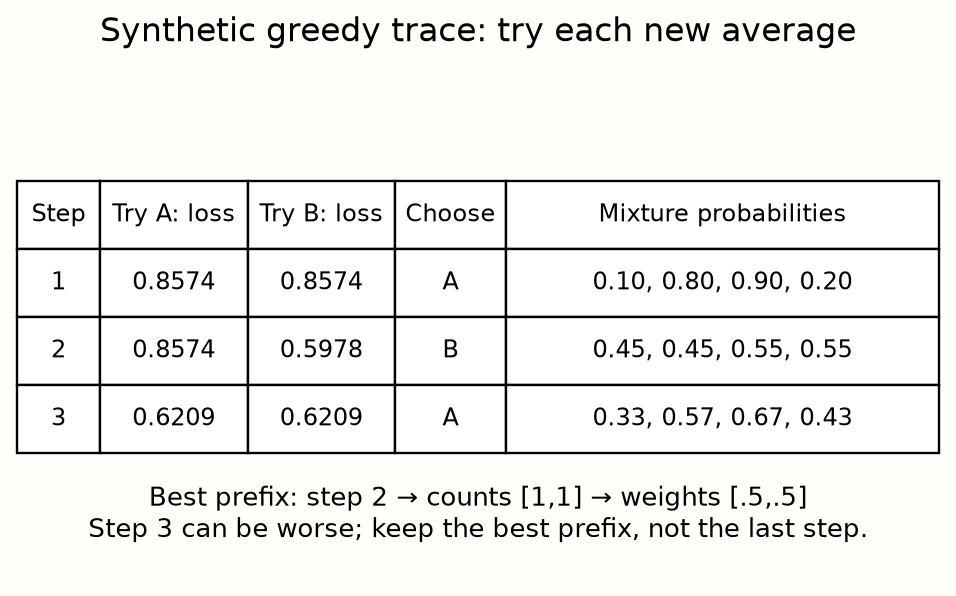

Synthetic trial mixtures: compare candidate losses at each step, then keep the best prefix.

In [ ]:
# PROVIDED — numeric log loss
def binary_loss(y, p):
    """Binary cross-entropy (natural logs); clip only for numerical stability."""
    y=np.asarray(y);p=np.asarray(p,dtype=float)
    if y.ndim!=1 or p.shape!=y.shape or not np.isin(y,[0,1]).all() or not np.isfinite(p).all():
        raise ValueError('Expected aligned binary targets and predictions')
    p=np.clip(p,1e-7,1-1e-7)
    return float(-np.mean(y*np.log(p)+(1-y)*np.log1p(-p)))

## TODO 4 · Fit the combiner
**Goal:** return (best_weights, history) using only OOF probabilities/labels. Start empty; at each positive integer step evaluate adding every column to the sum, choose minimum log loss (first-column ties within 1e-12), update counts/sum, and retain the first best prefix. Validate inputs using blend and binary_loss. **Why:** replacement converts counts into weights without test-label access. **Hint boundary:** divide a candidate sum by the number of selected members including the new one. History entries contain step, chosen, chosen_loss and losses (all candidate losses); no test argument belongs here.

In [ ]:
# TODO — greedy_select
def greedy_select(oof, y, steps=40):
    raise NotImplementedError("Implement the operation described above")

In [ ]:
# CHECK — replacement, best single and complementary members
y0=np.array([0,1]);z0=np.array([[.1,.8],[.9,.2]])
w,trace=greedy_select(z0,y0,7);np.testing.assert_array_equal(w,[1,0]);assert len(trace)==7
z1=np.array([[.1,.8],[.8,.1],[.9,.2],[.2,.9]]);y1=np.array([0,0,1,1])
w,tr=greedy_select(z1,y1,3);np.testing.assert_allclose(w,[.5,.5]);assert tr[-1]['chosen_loss']>tr[1]['chosen_loss']
assert binary_loss(y1,blend(z1,w))<=min(binary_loss(y1,z1[:,j]) for j in range(2))
print('PASS: replacement and best-prefix retention; test improvement is not guaranteed')

## PROVIDED · The known TabM branch, visible again
L054's corrected v2 numeric TabM-mini is reproduced below (one first input adapter, shared backbone biases, explicit fan-in initialization) in coherent parts. The mini variant shares backbone weights and biases; only its first input adapter and independent output heads differ by member. The final probability averages member softmax outputs. These definitions are used by the trainer below; the new lesson task is OOF combination, not rebuilding the L054 architecture. XGBoost and pretrained TabICL are provided base-model integrations.

In [ ]:
# PROVIDED — L054 / TabM paper §3
def kaiming_(t):
    """Linear-style U(-1/sqrt(d_in), +1/sqrt(d_in)) for [...,d_in,d_out].

    PyTorch's kaiming helper assumes [d_out,d_in] and is wrong for this layout.
    Explicit fan-in also handles the independent [k,d_in,d_out] heads.
    """
    bound = 1 / math.sqrt(t.shape[-2])
    return nn.init.uniform_(t, -bound, bound)

def sign_pm1(k, d, generator=None):
    """Random ±1 initialisation for the first adapter (paper §3.2: diversity)."""
    return torch.where(torch.rand(k, d, generator=generator) < .5, -1., 1.)

def batchensemble_linear(x, weight, R, S, bias):
    """BatchEnsemble layer over k members (paper §3.2).

    x: [B, k, d_in]; weight (shared W): [d_in, d_out]; R: [k, d_in] or None;
    S: [k, d_out] or None; bias (B): [k, d_out]. Returns [B, k, d_out] computed as
    ((x ⊙ R) W) ⊙ S + B, with R/S skipped when None (the mini variant).
    """
    if R is not None:
        x = x * R
    h = torch.einsum('bki,io->bko', x, weight)
    if S is not None:
        h = h * S
    return h + bias

def packed_head(h, weight, bias):
    """k independent output heads. h: [B,k,d]; weight: [k,d,d_y]; bias: [k,d_y]."""
    return torch.einsum('bkd,kdo->bko', h, weight) + bias

In [ ]:
# PROVIDED — L054 / TabM paper §3
def member_mean_loss(out, y, regression):
    """Mean over the k members of each member's loss (paper §5.1). out: [B,k,d_y]."""
    k = out.shape[1]
    if regression:
        return ((out[:, :, 0] - y.unsqueeze(1)) ** 2).mean()
    logp = out.log_softmax(-1)
    nll = -logp.gather(-1, y.view(-1, 1, 1).expand(-1, k, 1)).squeeze(-1)
    return nll.mean()

def ensemble_predict(out, regression):
    """Mean prediction over members: raw for regression, probabilities otherwise."""
    if regression:
        return out.mean(1)[:, 0]
    return out.softmax(-1).mean(1)

In [ ]:
# PROVIDED — L054 / TabM paper §3
class MLP(nn.Module):
    """Plain MLP baseline: N blocks of Linear→ReLU→Dropout, then a linear head.

    This is both the k=1 reference and the member architecture of the deep
    ensemble MLP^{×k}. Definition follows paper §3.3.
    """
    def __init__(self, din, width=64, depth=3, dropout=.1, regression=False, k=1):
        super().__init__()  # k is accepted and ignored so MLP and TabM share a signature
        dims = [din] + [width] * depth
        self.blocks = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(width, 1 if regression else 2)
        self.regression = regression

    def forward(self, x):
        h = x
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)

class BatchEnsembleLinear(nn.Module):
    """One shared W with per-member multiplicative (R,S) and additive (B) adapters.

    ``first`` selects the diversity-creating adapter that is initialised with
    random ±1; all other adapters are initialised so they have no effect at the
    start (later R=S=1, identical random bias rows), matching the ``TabM`` initialisation in paper §3.3.
    ``shared_rs`` (mini) keeps only the first R, with ordinary shared biases.
    There is no S even in the first mini layer; all later R/S are absent.
    """
    def __init__(self, din, dout, k, first=False, shared_rs=False, generator=None):
        super().__init__()
        self.k = k
        self.weight = nn.Parameter(kaiming_(torch.empty(din, dout)))
        # Full TabM starts each member bias with the same nn.Linear-style draw.
        base_bias = torch.empty(dout).uniform_(-1 / math.sqrt(din), 1 / math.sqrt(din))
        self.bias = nn.Parameter(base_bias if shared_rs else base_bias.repeat(k, 1))
        self.R = nn.Parameter(sign_pm1(k, din, generator) if first else torch.ones(k, din)) \
            if first or not shared_rs else None
        self.S = None if shared_rs else nn.Parameter(torch.ones(k, dout))

    def forward(self, x):                                          # x: [B, k, din]
        return batchensemble_linear(x, self.weight, self.R, self.S, self.bias)

class PackedHead(nn.Module):
    """k independent output heads (one per submodel); d_y is tiny so this is cheap."""
    def __init__(self, width, dy, k):
        super().__init__()
        self.weight = nn.Parameter(kaiming_(torch.empty(k, width, dy)))
        self.bias = nn.Parameter(torch.empty(k, dy).uniform_(-1 / math.sqrt(width), 1 / math.sqrt(width)))

    def forward(self, h):                                          # h: [B, k, width]
        return packed_head(h, self.weight, self.bias)

In [ ]:
# PROVIDED — L054 / TabM paper §3
class TabM(nn.Module):
    """One model imitating an ensemble of k MLPs (paper §3.3).

    forward returns per-member outputs of shape [B, k, d_y]. Use
    :meth:`predict` for the mean (ensemble) prediction and :meth:`member_losses`
    for the mean-over-members training objective.
    """
    def __init__(self, din, k=32, width=64, depth=3, dropout=.1,
                 regression=False, arch='mini', seed=0):
        super().__init__()
        assert arch in ('mini', 'tabm')
        g = torch.Generator().manual_seed(seed)
        self.k, self.regression, self.arch = k, regression, arch
        dims = [din] + [width] * depth
        shared_rs = arch == 'mini'
        self.blocks = nn.ModuleList(
            BatchEnsembleLinear(a, b, k, first=(i == 0), shared_rs=shared_rs, generator=g)
            for i, (a, b) in enumerate(zip(dims[:-1], dims[1:])))
        self.dropout = nn.Dropout(dropout)
        self.head = PackedHead(width, 1 if regression else 2, k)

    def forward(self, x):
        # 3-D inputs permit independent per-member batches in the closer track.
        h = x.unsqueeze(1).expand(-1, self.k, -1) if x.ndim == 2 else x
        if h.ndim != 3 or h.shape[1] != self.k:
            raise ValueError('Expected [B,din] or [B,k,din]')
        for block in self.blocks:
            h = self.dropout(torch.relu(block(h)))
        return self.head(h)                                       # [B,k,d_y]

    def predict(self, x):
        """Ensemble prediction: mean over members (probabilities if classifying)."""
        return ensemble_predict(self(x), self.regression)

    def member_losses(self, x, y):
        """Mean over the k members of each member's supervised loss (paper §5.1)."""
        return member_mean_loss(self(x), y, self.regression)

    def member_predictions(self, x):
        """Per-member predictions [B,k,(d_y)] for individual-vs-collective analysis."""
        out = self(x)
        if self.regression:
            return out[:, :, 0]
        return out.softmax(-1)

## PROVIDED · Training and evaluation protocol
Each fit uses only its supplied rows. Trees and neural epochs are fixed before evaluation, so there is no early-stopping leak. The optional TabICL branch supplies only these fitting rows as labeled context. It uses a released checkpoint; its internal architecture is an explicit API exception for this ensemble lesson.

Read oof_library closely: your train_indices and write_oof are invoked in its actual fold loop. Test probabilities use the very same models, averaged within each family. evaluate_library calls your greedy_select and blend; the best-single family is chosen by OOF loss before any test scoring.

In [ ]:
# PROVIDED — fixed presets
PRESETS={'smoke': {'cap': 360, 'folds': 3, 'epochs': 8, 'trees': 40, 'k': 4, 'width': 32, 'steps': 20, 'tfm_estimators': 1}, 'lab': {'cap': 750, 'folds': 3, 'epochs': 32, 'trees': 120, 'k': 8, 'width': 48, 'steps': 40, 'tfm_estimators': 1}, 'closer': {'cap': 2000, 'folds': 5, 'epochs': 64, 'trees': 300, 'k': 32, 'width': 128, 'steps': 40, 'tfm_estimators': 4}}
CHECKPOINT='tabicl-classifier-v1.1-0506.ckpt'

In [ ]:
# PROVIDED — visible load_binary
def load_binary(name, cap, seed=57):
    x,y=load_tier_a(name);x=x.to_numpy(dtype='float32');y=y.to_numpy(dtype='int64')
    if not np.array_equal(np.unique(y),[0,1]):raise ValueError('Binary datasets only')
    ids=np.arange(len(y));rng=np.random.default_rng(seed)
    ids=rng.permutation(ids)[:min(cap,len(ids))]
    dev,test=train_test_split(ids,test_size=.25,random_state=seed,stratify=y[ids])
    return dict(x=x[dev],y=y[dev],xt=x[test],yt=y[test],dev_ids=dev.tolist(),test_ids=test.tolist(),
                data_hash=hashlib.sha256((CACHE/f'{name}.parquet').read_bytes()).hexdigest(),
                openml_id=SPECS[name]['openml_id'])

In [ ]:
# PROVIDED — visible fit_predict
def fit_predict(kind, x, y, queries, seed, cfg, device='cpu', checkpoint=None):
    """Only fitting rows enter preprocessing/context/training. No validation labels."""
    if kind=='TabICL':
        from tabicl import TabICLClassifier
        model=TabICLClassifier(n_estimators=cfg['tfm_estimators'],device=device,random_state=seed,
              n_jobs=1,model_path=checkpoint,checkpoint_version=CHECKPOINT,allow_auto_download=checkpoint is None,
              use_amp=False)
        model.fit(x,y)
        return [model.predict_proba(q)[:,list(model.classes_).index(1)] for q in queries]
    prep=make_pipeline(SimpleImputer(strategy='median'),StandardScaler())
    z=prep.fit_transform(x).astype('float32');qs=[prep.transform(q).astype('float32') for q in queries]
    if kind=='XGB':
        model=XGBClassifier(n_estimators=cfg['trees'],max_depth=3,learning_rate=.05,
            subsample=.8,colsample_bytree=.8,tree_method='hist',n_jobs=1,random_state=seed,eval_metric='logloss')
        model.fit(z,y)
        return [model.predict_proba(q)[:,1] for q in qs]
    if kind!='TabM':raise ValueError('Unknown family: '+kind)
    torch.manual_seed(seed)
    model=TabM(z.shape[1],k=cfg['k'],width=cfg['width'],depth=3,dropout=.1,arch='mini',seed=seed).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=.002,weight_decay=0.)
    xt=torch.as_tensor(z,device=device);yt=torch.as_tensor(y,device=device)
    for _ in range(cfg['epochs']):
        model.train()
        for idx in torch.randperm(len(z),device=device).split(128):
            loss=model.member_losses(xt[idx],yt[idx]);opt.zero_grad();loss.backward();opt.step()
    model.eval()
    with torch.no_grad():return [model.predict(torch.as_tensor(q,device=device))[:,1].cpu().numpy() for q in qs]

In [ ]:
# PROVIDED — visible oof_library
def oof_library(data, families, seed, cfg, device='cpu', checkpoint=None):
    """Each dev row predicted once; test predictions averaged over the same fold models."""
    x,y=data['x'],data['y'];fold_ids=np.full(len(y),-1,int)
    for f,(_,held) in enumerate(StratifiedKFold(cfg['folds'],shuffle=True,random_state=57).split(x,y)):
        fold_ids[held]=f
    oof=np.full((len(y),len(families)),np.nan);seen=np.zeros(len(y),int)
    test_folds=[];audit=[]
    for f in range(cfg['folds']):
        tr=train_indices(fold_ids,f);held=np.flatnonzero(fold_ids==f)
        assert not set(tr)&set(held)
        fold_pred=[];fold_test=[]
        for kind in families:
            a,b=fit_predict(kind,x[tr],y[tr],[x[held],data['xt']],seed*100+f,cfg,device,checkpoint)
            fold_pred.append(a);fold_test.append(b)
        write_oof(oof,seen,held,np.column_stack(fold_pred))
        test_folds.append(np.column_stack(fold_test))
        audit.append(dict(fold=f,fit_rows=tr.tolist(),held_rows=held.tolist()))
    if not np.all(seen==1) or not np.isfinite(oof).all():raise ValueError('OOF coverage incomplete')
    return oof,np.mean(test_folds,axis=0),audit

In [ ]:
# PROVIDED — visible evaluate_library
def evaluate_library(oof, test, y, yt, families, steps=40):
    """Freeze all choices using OOF before reading test labels for scores."""
    weights,trace=greedy_select(oof,y,steps)
    chosen=int(np.argmin([binary_loss(y,oof[:,j]) for j in range(len(families))]))
    predictions={name:test[:,j] for j,name in enumerate(families)}
    predictions['OOF-best']=test[:,chosen]
    predictions['Uniform']=blend(test,np.ones(len(families))/len(families))
    predictions['Greedy-stack']=blend(test,weights)
    errors={a:binary_loss(yt,p) for a,p in predictions.items()}
    return dict(errors=errors,weights=weights.tolist(),selected=families[chosen],trace=trace,
      oof_losses={a:binary_loss(y,oof[:,j]) for j,a in enumerate(families)},
      residual_correlation=np.corrcoef((oof-y[:,None]).T).tolist(),
      paired_gap=errors['Greedy-stack']-errors['OOF-best'])

In [ ]:
# PROVIDED — visible summarize
def summarize(rows):
    names=list(dict.fromkeys(r['dataset'] for r in rows));arms=list(rows[0]['errors']);table={}
    for name in names:
        rs=[r for r in rows if r['dataset']==name];table[name]={}
        for a in arms+['paired_gap']:
            v=np.array([r['errors'][a] if a in arms else r[a] for r in rs]);n=len(v)
            sd=float(v.std(ddof=1)) if n>1 else None
            half=float(t.ppf(.975,n-1)*sd/np.sqrt(n)) if n>1 else None
            table[name][a]=dict(mean=float(v.mean()),sd=sd,ci95=None if n<2 else [float(v.mean()-half),float(v.mean()+half)])
    means=np.array([[table[n][a]['mean'] for a in arms] for n in names]);ranks=rankdata(means,axis=1)
    stat=friedmanchisquare(*means.T) if len(names)>1 else None
    cd=float(studentized_range.ppf(.95,len(arms),np.inf)/np.sqrt(2)*np.sqrt(len(arms)*(len(arms)+1)/(6*len(names))))
    return dict(table=table,arms=arms,mean_ranks=dict(zip(arms,ranks.mean(0).tolist())),
       per_dataset_ranks=ranks.tolist(),friedman_p=float(stat.pvalue) if stat else None,nemenyi_cd=cd,
       uncertainty='Paired training-seed t intervals conditional on fixed rows and folds; not population confidence.')

In [ ]:
# PROVIDED — visible run_suite
def run_suite(preset='lab',names=('diabetes','blood_transfusion','phoneme'),seeds=(0,1,2),
              include_tfm=False,device='cpu',checkpoint=None,output_dir='data/cache/l057',on_progress=True):
    cfg=PRESETS[preset];families=['XGB','TabM']+(['TabICL'] if include_tfm else [])
    root=Path(output_dir);root.mkdir(parents=True,exist_ok=True);torch.set_num_threads(1)
    start=time.perf_counter();rows=[];datasets={}
    with threadpool_limits(limits=1):
        for name in names:
            data=load_binary(name,cfg['cap']);datasets[name]={k:v for k,v in data.items() if k not in ('x','y','xt','yt')}
            for seed in seeds:
                oof,test,audit=oof_library(data,families,seed,cfg,device,checkpoint)
                r=evaluate_library(oof,test,data['y'],data['yt'],families,cfg['steps']);r.update(dataset=name,seed=seed)
                rows.append(r)
                np.savez_compressed(root/f'{name}-{seed}.npz',oof=oof,test=test,y=data['y'],yt=data['yt'])
                (root/f'{name}-{seed}-folds.json').write_text(__import__('json').dumps(audit))
                if on_progress:print(name,seed,r['errors'],r['weights'],flush=True)
    versions={p:importlib.metadata.version(p) for p in ['numpy','scipy','scikit-learn','torch','xgboost']+(['tabicl'] if include_tfm else [])}
    return dict(preset=preset,config=cfg,families=families,seeds=list(seeds),split_seed=57,fold_seed=57,
        datasets=datasets,rows=rows,summary=summarize(rows),versions=versions,seconds=time.perf_counter()-start,
        checkpoint_sha256=hashlib.sha256(Path(checkpoint).read_bytes()).hexdigest() if checkpoint else None,
        verdict='INCOMPARABLE',scope='OOF stack with fixed recipes; not TabArena Figure 6 reproduction')

## TODO 5 · Measure a family's conditional usefulness
**Goal:** return one record per removed family after relearning the combiner using the remaining OOF columns. **Why:** deleting and renormalizing old weights does not measure replaceability. **Hint boundary:** call evaluate_library once on all families, then once for each reduced column set. Expand each reduced weight vector back to the original family order with zero for the removed family. Do not inspect test scores to choose weights.

Each record needs removed, removed_index, weights, selected (OOF-selected single), original_weight, test_loss (reduced Greedy-stack), test_gap (reduced loss minus full Greedy-stack loss), and oof_loss (reduced mixture loss). Use blend/binary_loss for the last field. Reject fewer than two families. Positive test_gap favors inclusion; this is a conditional removal experiment, not causal importance.

In [ ]:
# TODO — family_ablation
def family_ablation(oof, test, y, yt, families, steps=40):
    raise NotImplementedError("Implement the operation described above")

In [ ]:
# CHECK — a duplicate can replace the member with weight one
za=np.array([[.1,.1,.9],[.2,.2,.9],[.8,.8,.1],[.9,.9,.1]]);ya=np.array([0,0,1,1])
removed=family_ablation(za,za,ya,ya,['A','copy-A','bad'],8)
assert removed[0]['original_weight']==1 and abs(removed[0]['test_gap'])<1e-12
assert removed[0]['weights'][0]==0 and removed[0]['weights'][1]==1
changed=family_ablation(za,za,ya,1-ya,['A','copy-A','bad'],8)
assert [r['weights'] for r in removed]==[r['weights'] for r in changed]
print('PASS: weight one can be replaceable; test-label changes cannot change selection')

## Run your OOF pipeline on real rows
This fresh CPU smoke run uses diabetes, two known families, seed0, cap360, three folds, 8epochs/40trees. It checks the implementation; it is not the main evidence table. Predict whether the greedy stack must improve test log loss before running. The full three-family author analysis follows.

In [ ]:
# PROVIDED — fresh fit driven by your four functions
fresh=run_suite('smoke',names=('diabetes',),seeds=(0,),include_tfm=False,output_dir='data/cache/l057-student')
display(pd.DataFrame([fresh['rows'][0]['errors']]))
audit=json.loads(Path('data/cache/l057-student/diabetes-0-folds.json').read_text())
assert all(not set(f['fit_rows']) & set(f['held_rows']) for f in audit)
assert sorted(i for f in audit for i in f['held_rows'])==list(range(len(fresh['datasets']['diabetes']['dev_ids'])))
print('PASS: real-row disjointness and exact-once OOF coverage')

## Audit all three families on all three datasets
The following are **author-reference predictions**, not fits from your current kernel. The v2 library combines 27 newly trained corrected TabM fold models with the exact archived XGB and TabICL columns (54 earlier fold-fit/context constructions). Row IDs, labels, fold assignments and data hashes were checked before replacing the TabM column. This is a declared hybrid artifact, not 81 fresh fits. The same outer test was previously inspected; the corrected measurements are exploratory. Hashes protect exact arrays; the contract records fit recipes and checkpoint identity. Recompute their weights and test scores using your functions. Do not use test labels to change those weights.

Report mean±sample SD for each dataset and a paired stack-minus-OOF-best interval. These intervals condition on fixed rows/folds; they do not measure generalization over new datasets. A zero-width interval from an identical selected model is not proof of population equivalence.

In [ ]:
# PROVIDED — hash-verified corrected hybrid audit
provenance=json.loads((ROOT/'_data_l057_v2.json').read_text());reference=json.loads((ROOT/'_verify_l057_v2_results.json').read_text())
rows=[]
for entry in provenance['predictions']:
    path=ROOT/entry['path'];assert hashlib.sha256(path.read_bytes()).hexdigest()==entry['sha256']
    with np.load(path) as q:
        assert q['families'].tolist()==reference['families'] and q['classes'].tolist()==[0,1]
        np.testing.assert_array_equal(q['dev_ids'],reference['datasets'][entry['dataset']]['dev_ids'])
        oldpath=ROOT/entry['archive_path'];assert hashlib.sha256(oldpath.read_bytes()).hexdigest()==entry['archive_sha256']
        with np.load(oldpath) as old:
            for key in ['oof','test']:
                np.testing.assert_array_equal(q[key][:,[0,2]],old[key][:,[0,2]])
            for key in ['y','yt']:np.testing.assert_array_equal(q[key],old[key])
        row=evaluate_library(q['oof'],q['test'],q['y'],q['yt'],reference['families'],reference['config']['steps'])
    row.update(dataset=entry['dataset'],seed=entry['seed']);rows.append(row)
    original=next(r for r in reference['rows'] if r['dataset']==entry['dataset'] and r['seed']==entry['seed'])
    np.testing.assert_allclose(row['weights'],original['weights'],atol=1e-12)
    np.testing.assert_allclose(list(row['errors'].values()),list(original['errors'].values()),atol=1e-12)
summary=summarize(rows)
for dataset,table in summary['table'].items():
    print(dataset);display(pd.DataFrame(table).T[['mean','sd','ci95']])
print('Mean ranks:',summary['mean_ranks'],'Friedman p:',summary['friedman_p'],'Nemenyi CD:',summary['nemenyi_cd'])
Path('data/cache/l057-student-audit.json').write_text(json.dumps(summary,indent=2))
print('PASS: all 9 three-family runs match from your live functions')

## Run your removal experiment on the corrected library
Predict which family removal will hurt most before running. Hold predictions and selection steps fixed. These are exploratory paired comparisons on reused test rows. Use a positive removal gap to mean that including the family helped. Do not select a new final pipeline from the resulting test table.

In [ ]:
# PROVIDED — TODO 5 is the actual experiment, not an isolated exercise
ablation_rows=[]
for entry in provenance['predictions']:
    with np.load(ROOT/entry['path']) as q:
        for row in family_ablation(q['oof'],q['test'],q['y'],q['yt'],reference['families'],reference['config']['steps']):
            row.update(dataset=entry['dataset'],seed=entry['seed']);ablation_rows.append(row)
assert ablation_rows==reference['ablations']
removal=pd.DataFrame(ablation_rows)
display(removal.groupby(['dataset','removed'])[['original_weight','test_gap']].agg(['mean','std']))
Path('data/cache/l057-student-ablation.json').write_text(json.dumps(ablation_rows,indent=2))
print('PASS: 27 family-removal experiments match from your live TODO')

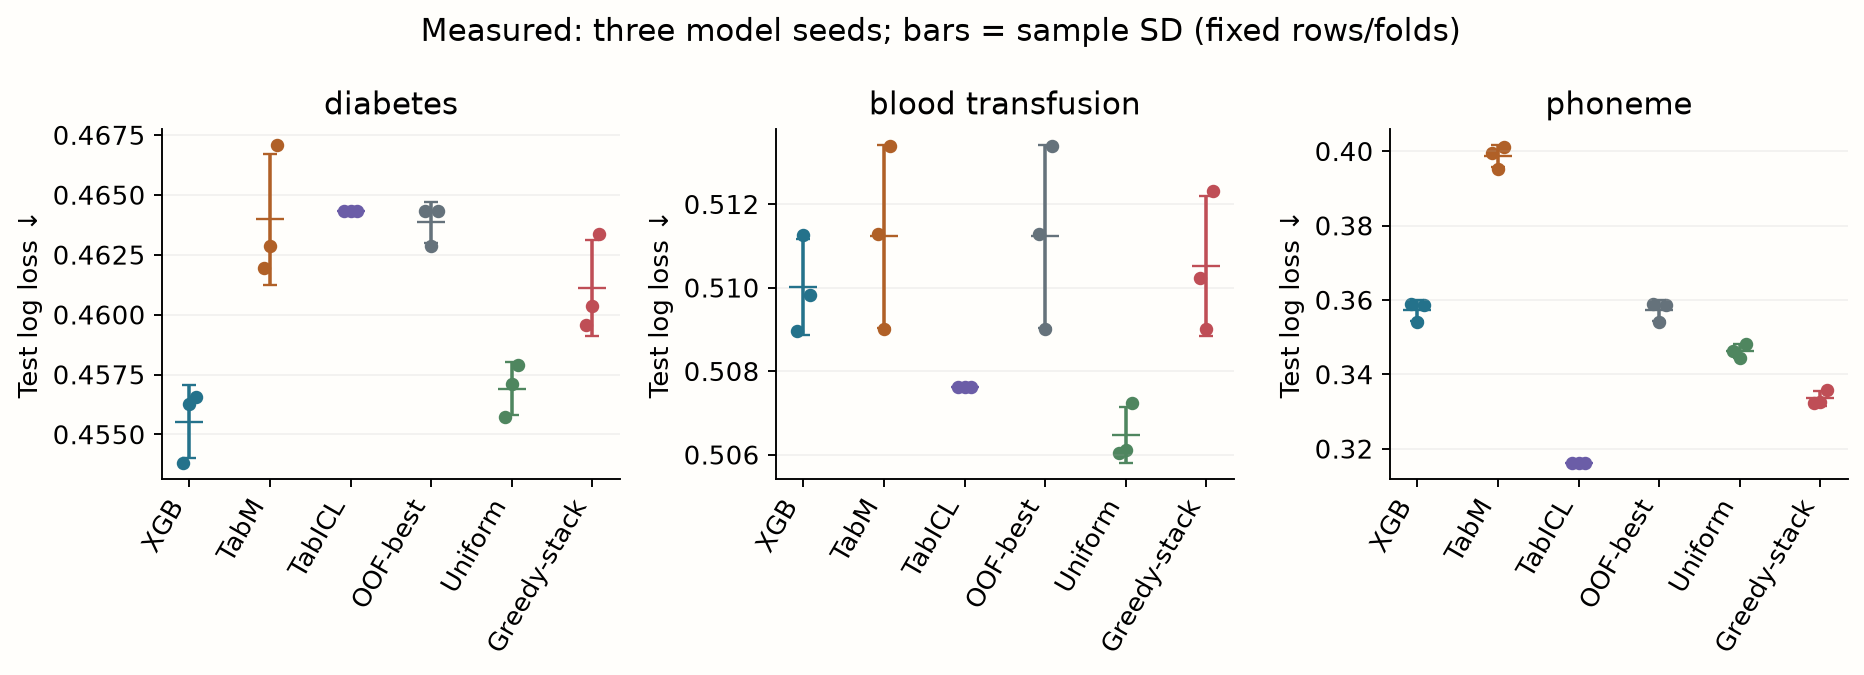

Author-reference evidence: every seed shown; bars are sample SD, not confidence intervals.

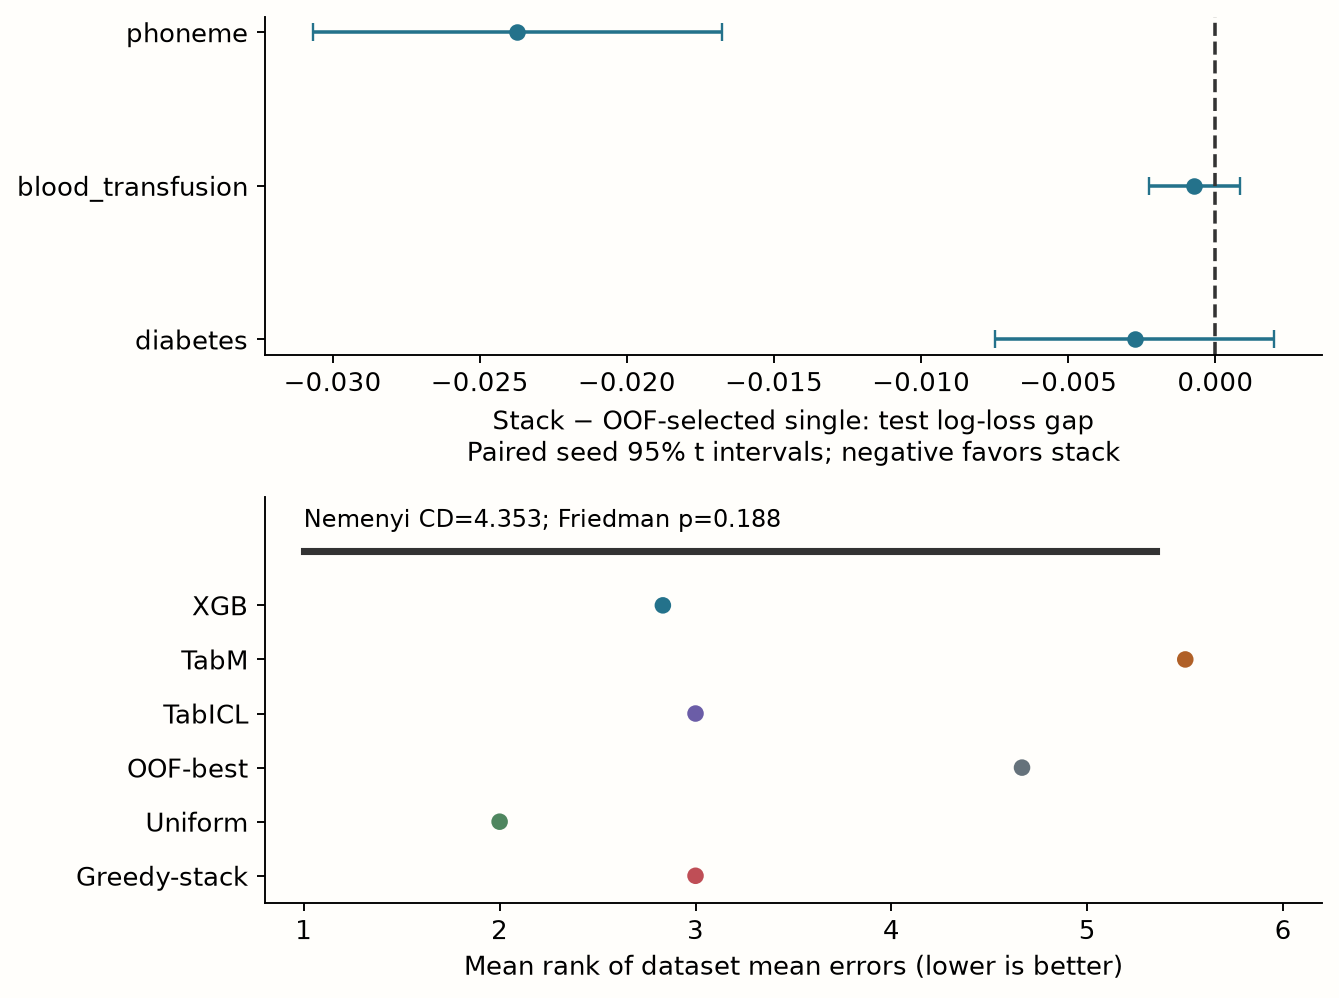

Author-reference paired seed intervals and dataset-balanced ranks; three datasets provide little power.

## Trace one saved row through the fitted combiner
Pick the first saved dataset/seed and first test row by position, not by its result. Before running, predict its weighted probability from the displayed contributions. Explain which class the number describes and when its target is allowed to enter this calculation. The selected family and weights use development labels; the row's test target enters only the final loss.

In [ ]:
# PROVIDED — expose input probabilities, weights, contributions, output and metric
entry=provenance['predictions'][0]
with np.load(ROOT/entry['path']) as q:
    weights,_=greedy_select(q['oof'],q['y'],reference['config']['steps'])
    row_probability=blend(q['test'][:1],weights)[0]
    display(pd.DataFrame({'family':reference['families'],'probability_y1':q['test'][0],
                         'weight':weights,'weighted_contribution':q['test'][0]*weights}))
    row_trace={'original_test_row_id':int(q['test_ids'][0]),'probability_y1':float(row_probability),
               'target':int(q['yt'][0]),'log_loss_nats':binary_loss(q['yt'][:1],np.array([row_probability]))}
    assert np.isclose(row_probability,(q['test'][0]*weights).sum())
print(row_trace)

**Connecting the ideas.** A valid stack can still fail to improve. Compare against the single model chosen without test labels and interpret the paired differences. The best observed test model is an oracle reference, not an eligible selection rule.

## Interpretation checkpoint
Before inspecting the source report again, answer: Which dataset improves against the OOF-selected single? Does any worsen? Is that the same as beating every individually measured test score? Why can an ensemble assign weight to a weaker test model? What extra matched-budget experiment is needed to compare cross-family and within-family diversity?

### Separate a useful local gain from a mechanism claim

Compare the ensemble against the best member selected by the same validation policy, not an oracle member chosen retrospectively on test. Also include a simple uniform average. If learned weights do not beat uniform averaging, the extra adaptation may not be worth its complexity under the current sample size.

Use paired differences on identical test rows and average repetitions within each dataset before broad summaries. A small gain on one dataset can be real and useful locally while remaining weak evidence for universal cross-family superiority. Report the local effect and the limits separately.

Cost is additive in a way a final score is not. A stack may require several fold fits per family and multiple base predictions per query. Distinguish one-time OOF construction cost, final fitted storage and serving latency. A low-cost single model may remain preferable when the ensemble gain is smaller than a practical tolerance.

If a member receives nearly zero weight, do not immediately conclude its architecture is useless. It may be redundant with another member under this split, poorly calibrated, insufficiently tuned or harmed by the representation used. Diagnose with an ablation that holds the other predictions fixed before launching a new training campaign.

For the exit artifact, save the fold assignment, OOF row IDs, class order, combiner parameters and test predictions. Then explain one row from base outputs through the weighted result to its metric contribution. This makes the ensemble an inspectable procedure rather than a final number with several model names attached.

### A weight is a fitted coefficient; removal is a new experiment

Suppose A and B are duplicate predictors and the deterministic tie rule selects A alone. A receives weight one, B zero. Removing A lets the selector choose B and leaves every prediction unchanged. The weight suggests total dependence on A; the removal experiment shows that A is replaceable **within this library**. This is why the new live TODO implements reselection, rather than deleting A from the old weight vector and renormalizing it. If A carried all the original weight, that shortcut is not even defined.

For a family j define Δⱼ=loss(test, reselected stack without j)−loss(test, full selected stack). A positive value means the available family helped this particular selected procedure; a negative value means removal improved its measured test score. Keep the original OOF/test arrays, labels, seeds, step limit and other families fixed. Change only candidate availability. Fit every reduced selector on OOF labels before using any test label. The notebook exports its zero-padded weights in the original family order, making the removed coefficient visibly zero.

This comparison measures conditional usefulness after selection. It is not a causal attribution, Shapley value, or estimate of what would happen after retuning all remaining base families with the saved compute. Different candidate libraries can change the answer. Likewise, three seeds of one family versus three different families match the number of probability columns but not training cost, hyperparameter search effort or inference latency. A fair cost claim requires those budgets to be measured and matched separately.

### Diagnose a failed ensemble before scaling it up

First verify row IDs and the positive-class schema. Second compare OOF versus test loss for the selected single and the selected blend. A strong OOF gain with a test regression suggests selection noise or distribution mismatch, not automatically a broken averaging formula. Third inspect whether two family columns are effectively duplicates and whether one is confidently wrong. Fourth compare against uniform weights, which avoid fitted weight selection. Finally run the leave-family-out analysis, keeping every choice off test labels.

The v2 correction changes the TabM operator because source inspection identified an architecture error, not because a test score was disappointing. Even so, these test rows have already been examined in the historical lesson. The revised measurements and ablations are **exploratory evidence on reused test rows**. Training seeds quantify variability conditional on that fixed split; they do not make this a newly untouched confirmatory evaluation. A confirmatory follow-up freezes the corrected recipe and evaluates new prespecified outer splits or tasks once.

**Teach-back checkpoint:** explain why base cross-fitting, combiner evaluation and portfolio transfer require three distinct boundaries. Then explain why a nonzero removal gap and a large weight answer different questions. Your EXIT must include a concrete row trace, original and reduced weights, the sign of the paired gap, and the declared inference policy.

In [ ]:
# EXIT — submit this artifact AND your written interpretation
exit_artifact={'fresh_training':'two-family diabetes smoke; one seed',
 'corrected_hybrid_audit':'27 corrected TabM fits + 54 archived XGB/TabICL fit-context constructions; live audit only',
 'summary':summary,'family_ablation':ablation_rows,'prediction_provenance':provenance,
 'row_trace':row_trace,'current_model':'relkit/tabm_v2.py','test_status':'reused; exploratory','paper_verdict':'INCOMPARABLE','larger_run':'NOT_RUN unless gate below executed'}
Path('data/cache/l057-exit.json').write_text(json.dumps(exit_artifact,indent=2))
print('Saved data/cache/l057-exit.json. Add the OOF coverage, weights, identities and interpretation required above.')

## Required next experiment · fresh three-family stack and larger run
The curriculum target includes XGB + TabM + TabICL. The author has measured the small three-family track; now run it with your implementation when ready, then run the larger preset. Installation is separate so the main notebook does not download unused foundation-model dependencies. `RUN_THREE_FAMILY=False` deliberately skips the download/training; it does not count as completing this track.

Choose `lab` to train all three families afresh with the corrected v2 TabM recipe (3folds, cap750, one TabICL view). Choose `closer` for 5folds, cap2000, TabM k32/width128/64epochs, 300trees, four TabICL views. Both use three seeds. GPU recommended for closer; do not claim a known Colab runtime before measuring it. Artifacts go into a persistent directory you choose; free Colab storage is ephemeral.

For unattended GPU execution: `modal run --detach modal/l057_paper_repro.py --preset closer` from the repository root, then `modal volume get relational-l057 closer-results.json .`. The cloud operator uses the canonical completed functions; the cell below uses **your live notebook functions**. This is a larger comparison, not a faithful TabArena paper preset. Full Figure 6 requires its original task/method roster, predictions, metric, folds, selection policy and evaluator; see the contract.

In [ ]:
# PROVIDED — deliberate install/training gate (off by default)
RUN_THREE_FAMILY=False
PRESET='closer' # 'lab' trains the corrected three-family recipe afresh
if RUN_THREE_FAMILY:
    import subprocess
    subprocess.check_call([sys.executable,'-m','pip','install','-r',str(ROOT/'requirements-l057-tfm.txt')])
    from _fetch_l057 import fetch
    device='cuda' if torch.cuda.is_available() else 'cpu'
    larger=run_suite(PRESET,include_tfm=True,device=device,checkpoint=fetch(),output_dir='data/cache/l057-live-'+PRESET)
    Path('data/cache/l057-live-'+PRESET+'-results.json').write_text(json.dumps(larger,indent=2))
    print(larger['summary']);print('INCOMPARABLE to Figure 6; compare the new paired gaps to the author lab.')
else:
    print('Fresh three-family / larger student run NOT_RUN. Author measured lab evidence is separate.')

## Conclusion ledger
| Bucket | Status | Meaning |
|---|---|---|
| Your fresh CPU run | RUN after successful cells | Two-family one-dataset smoke; implementation check |
| Corrected hybrid library | RUN / ARCHIVED; audit MATCH after CHECK | 27 corrected fits plus 54 unchanged archived fit/context constructions |
| Source selector check | 5 synthetic MATCH; actual 4/9 MATCH | 5 real libraries differ under upstream rounding; modified unrounded reference matches all 9 |
| TabArena Figure 6 | CITED / INCOMPARABLE | Original full benchmark not regenerated |
| Larger student / Modal track | NOT_RUN until executed | More compute and changed recipe, still not paper fidelity |
| Browser / live Colab / publication | See delivery record | Local execution and image payload checks do not verify those frontends |

Ask the tutor about any failed CHECK or conclusion you cannot justify. Submit your EXIT plus prose for feedback. Completing the notebook is evidence; reading an author table alone is not mastery.

## Carry this forward

<a href="../lessons/0058-surveys-meta-benchmarks.html">The survey lesson</a> steps back to organize these families and evidence types. That map will be useful only if it preserves the procedural distinctions we have just built.